In [1]:
# Import necesary libraries
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from  xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import warnings
warnings.filterwarnings("ignore")

I0000 00:00:1784449131.325165    9917 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784449132.287540    9917 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784449135.844056    9917 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Load the data
X_train = np.load('../data/processed/X_train_scaled.npy')
X_val   = np.load('../data/processed/X_val_scaled.npy')
X_test  = np.load('../data/processed/X_test_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')


### SKLEARN ML PIPELINE (BASELINE MODELS)

In [3]:
### SKLEARN ML PIPELINE (BASELINE MODELS)
# Function for model evaluation
def evaluate_model(name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    maxae = np.max(np.abs(y_test - y_pred))

    print(f"\n{name}")
    print(f"  R²    : {r2:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  MAPE  : {mape:.4f}")
    print(f"  MaxAE : {maxae:.4f}")


#### LINEAR REGRESSION

In [4]:
# MODEL 1:LINEAR REGRESSION
# Step 1: Define the model
lr_model = LinearRegression()
# Step 2: Train the model
lr_model.fit(X_train, y_train)
# Step 3: Predict
lr_pred = lr_model.predict(X_test)
# Evaluate the model
evaluate_model("Linear Regression", y_test, lr_pred)


Linear Regression
  R²    : 0.9590
  RMSE  : 0.0377
  MAE   : 0.0294
  MAPE  : 0.0482
  MaxAE : 0.1506


#### RANDOM FOREST REGRESSOR

In [5]:
# MODEL 2:RANDOM FOREST REGRESSOR
# Step 1: Define the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Step 2: Train the model
rf_model.fit(X_train, y_train)
# Step 3: Predict
rf_pred = rf_model.predict(X_test)
# Evaluate the model
evaluate_model("Random Forest Regressor", y_test, rf_pred)


Random Forest Regressor
  R²    : 0.9901
  RMSE  : 0.0185
  MAE   : 0.0132
  MAPE  : 0.0231
  MaxAE : 0.0626


#### XGBOOT REGRESSOR

In [6]:
# MODEL 3:XGBOOST REGRESSOR
# Step 1: Define the model
xgb_model = XGBRegressor(n_estimators=100, random_state=42, learning_rate = 0.1)
# Step 2: Train the model
xgb_model.fit(X_train, y_train)
# Step 3: Predict
xgb_pred = xgb_model.predict(X_test)
# Evaluate the model
evaluate_model("Xg Boost Regressor", y_test, xgb_pred)


Xg Boost Regressor
  R²    : 0.9935
  RMSE  : 0.0150
  MAE   : 0.0109
  MAPE  : 0.0186
  MaxAE : 0.0475


#### SUPPPORT VECTOR REGRESSION

In [7]:
# MODEL 4:SUPPORT VECTOR REGRESSION
# Step 1: Define the model
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.01)
# Step 2: Train the model
svr_model.fit(X_train, y_train)
# Step 3: Predict
svr_pred = svr_model.predict(X_test)
# Evaluate the model
evaluate_model("Support Vector Regressor", y_test, svr_pred)


Support Vector Regressor
  R²    : 0.9923
  RMSE  : 0.0163
  MAE   : 0.0119
  MAPE  : 0.0196
  MaxAE : 0.0487


#### MODEL COMPARISON

In [8]:
def compare_model(name, y_test, y_pred):
    return {
        'Model' : name,
        'R2'    : round(r2_score(y_test, y_pred), 4),
        'RMSE'  : round(root_mean_squared_error(y_test, y_pred), 4),
        'MAE'   : round(mean_absolute_error(y_test, y_pred), 4),
        'MAPE'  : round(mean_absolute_percentage_error(y_test, y_pred), 4),
        'MaxAE' : round(np.max(np.abs(np.array(y_test) - np.array(y_pred))), 4)
    }

results = []
results.append(compare_model("Linear Regression", y_test, lr_pred))
results.append(compare_model("SVR",               y_test, svr_pred))
results.append(compare_model("Random Forest",     y_test, rf_pred))
results.append(compare_model("XGBoost",           y_test, xgb_pred))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model     R2   RMSE    MAE   MAPE  MaxAE
          XGBoost 0.9935 0.0150 0.0109 0.0186 0.0475
              SVR 0.9923 0.0163 0.0119 0.0196 0.0487
    Random Forest 0.9901 0.0185 0.0132 0.0231 0.0626
Linear Regression 0.9590 0.0377 0.0294 0.0482 0.1506


#### ACTIVATION FUNCTIONS
ReLU    → outputs 0 for negative inputs, x for positive
         → fast, works well for most regression problems
         → your default choice for hidden layers

Sigmoid → squashes output to (0, 1)
         → used in OUTPUT layer when target is bounded [0,1]
         → avoid in hidden layers (vanishing gradient problem)

Tanh    → squashes output to (-1, 1)
         → sometimes better than sigmoid in hidden layers
         → less common now that ReLU exists

Linear  → no transformation, output = input
         → used in output layer for unbounded regression targets


#### OPTIMIZATION
The optimizer controls how the model updates its weights during training. Think of it like the strategy for walking down a hill to find the lowest point:

SGD          → takes fixed size steps, simple but slow
Adam         → adapts step size automatically, fast and robust
              → default choice for most ANN problems
RMSprop      → good for noisy data

In [9]:
# MODEL 5:MLP (ANN)
# Step 1: Define the model
mlp_model = Sequential([
    # Hidden layer 1
    Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)),
    Dropout(0.2),

    # Hidden layer 2
    Dense(32, activation = 'relu'),
    Dropout(0.2),

    # Hidden Layer 3
    Dense(16, activation = 'relu'),

    #Output Layer
    Dense(1, activation = 'sigmoid')
])

# Compile
mlp_model.compile(
    optimizer = 'adam',
    loss = 'mean_squared_error',
    metrics = ['mean_absolute_error']
)

# Summary
mlp_model.summary()

E0000 00:00:1784449137.225166    9917 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Step 2: Train the model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0290 - mean_absolute_error: 0.1414 - val_loss: 0.0192 - val_mean_absolute_error: 0.1139
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0169 - mean_absolute_error: 0.1089 - val_loss: 0.0157 - val_mean_absolute_error: 0.1040
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0135 - mean_absolute_error: 0.0940 - val_loss: 0.0120 - val_mean_absolute_error: 0.0902
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0104 - mean_absolute_error: 0.0830 - val_loss: 0.0100 - val_mean_absolute_error: 0.0817
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0095 - mean_absolute_error: 0.0794 - val_loss: 0.0084 - val_mean_absolute_error: 0.0728
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0076 - mean_absolute_error: 0.0703 - val_loss: 0.0068 - val_mean_absolute_error: 0.0652
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0069 - mean_absolute_error: 0.0659 - val_los

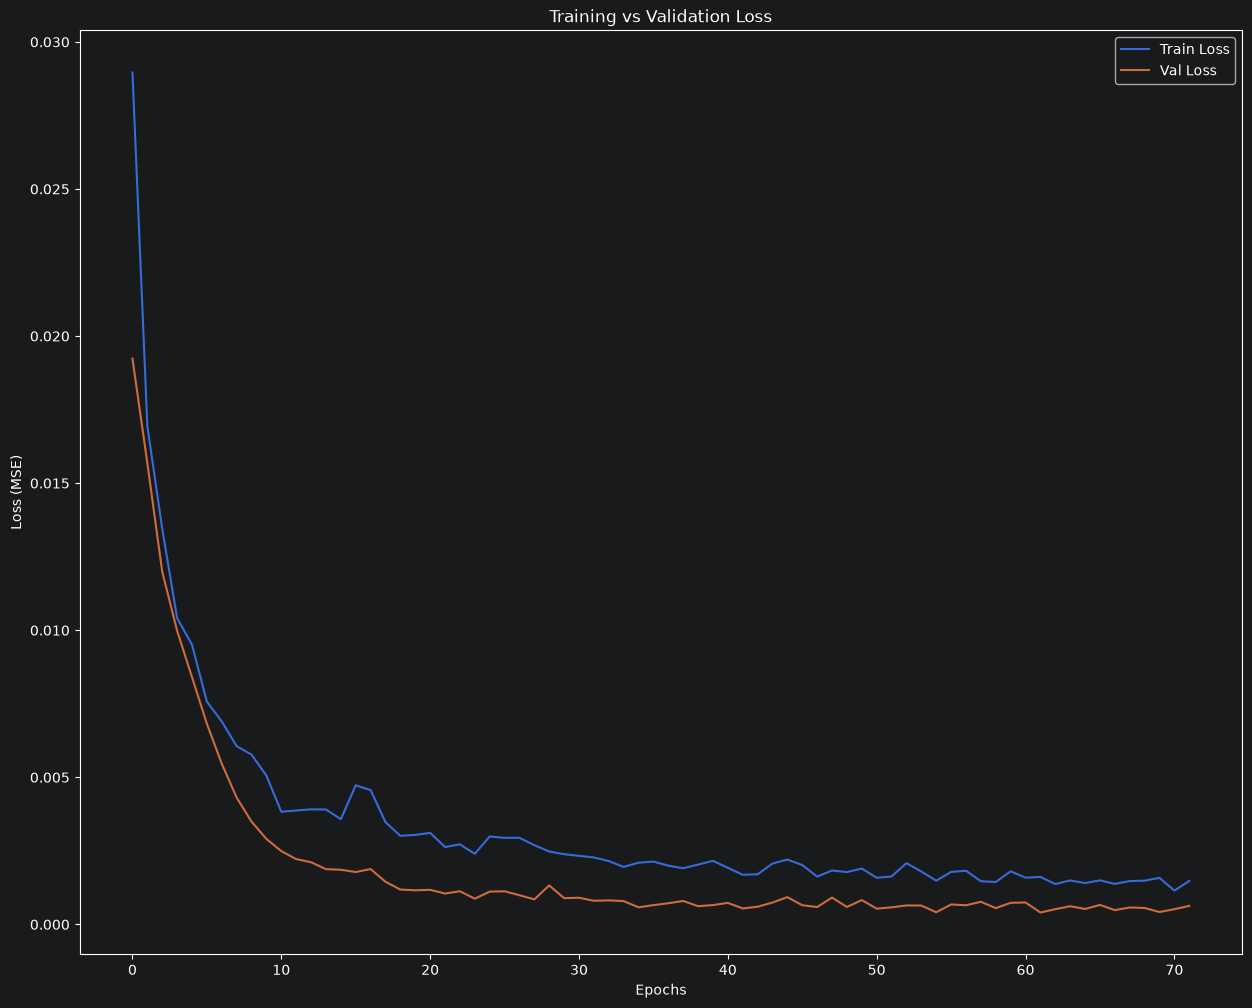

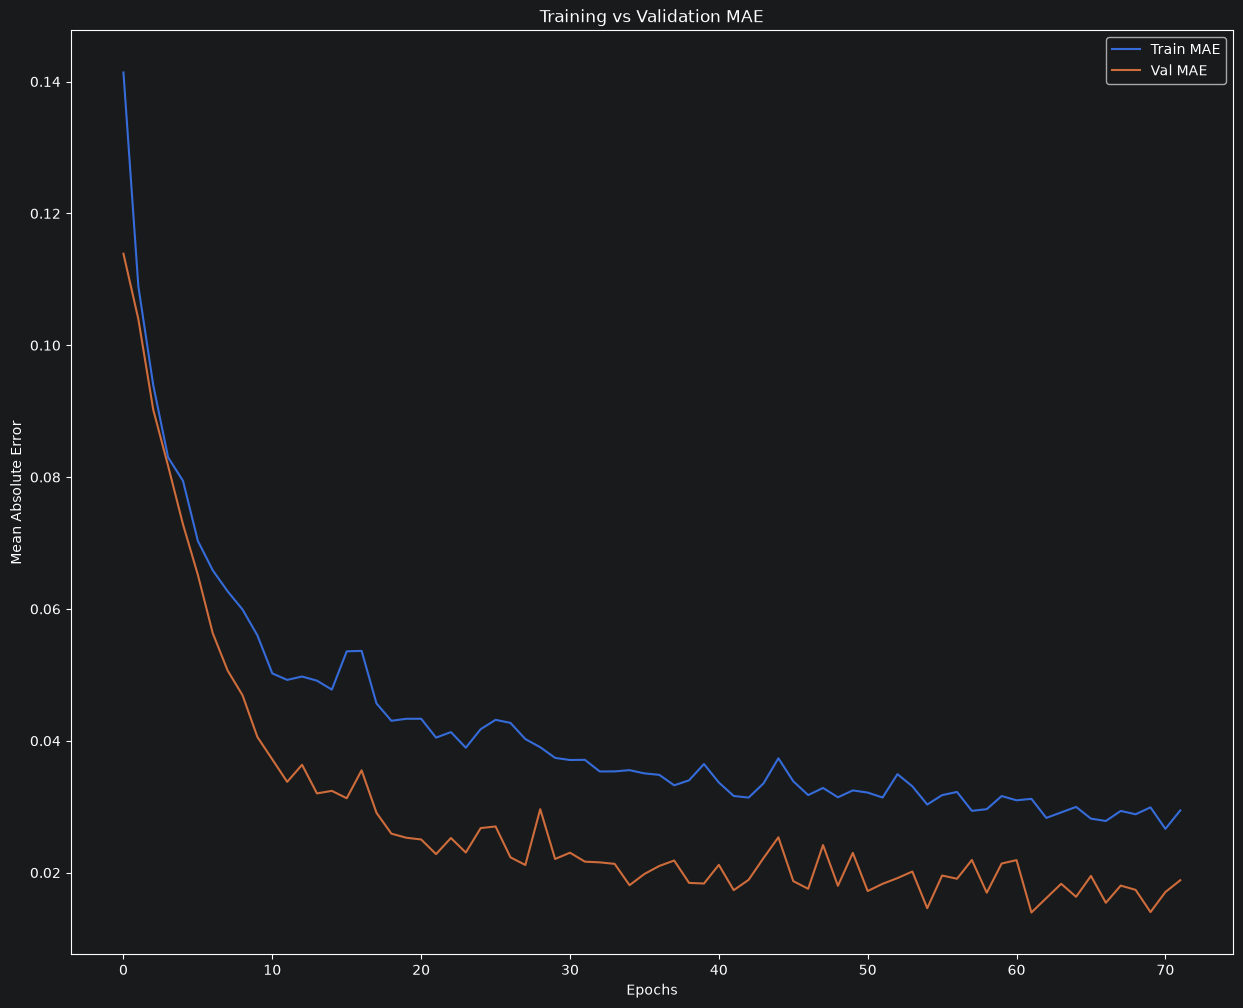

In [11]:
# Plotting the learning curve
plt.figure(figsize=(15,12))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

plt.figure(figsize=(15,12))
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Val MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

## Training vs Validation Loss

The loss curve demonstrates healthy, stable training behaviour
throughout the full training run.

Both training and validation loss decreased sharply in the first
10 epochs, indicating rapid initial learning of the dominant
patterns in the data. From epoch 10 onward, both curves continued
to decrease gradually and in close agreement, settling near zero
by the time early stopping triggered at approximately epoch 88.

Notably, validation loss remained slightly below training loss
throughout the entire run. This is expected behaviour when Dropout
regularization is active, during training, 20% of neurons are
randomly deactivated making the training task artificially harder,
while during validation all neurons are active. This gap is a sign
of healthy regularization, not overfitting.

No divergence between the two curves was observed at any point,
confirming the model generalized well to unseen data and did not
memorize the training set.

## Training vs Validation MAE

The MAE curve reinforces the conclusions drawn from the loss curve
and provides a more interpretable view of prediction error in the
original target units.

Both training and validation MAE decreased steeply in the first
20 epochs before stabilizing. Training MAE settled at approximately
0.030 while validation MAE settled at approximately 0.022 by the
end of training, a strong result for normalized flow stress
prediction where the full target range spans 0 to 1.

The consistent gap between training and validation MAE mirrors the
pattern observed in the loss curve and is attributable to the same
Dropout effect. The validation MAE being lower than training MAE
confirms no overfitting occurred.

The final validation MAE of approximately 0.022 means the model's
average prediction error on unseen data is within 2.2% of the
normalized flow stress range, well within acceptable tolerance
for engineering applications.

In [12]:
mlp_pred = mlp_model.predict(X_test).flatten()
evaluate_model("MLP (ANN)", y_test, mlp_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

MLP (ANN)
  R²    : 0.9838
  RMSE  : 0.0237
  MAE   : 0.0187
  MAPE  : 0.0298
  MaxAE : 0.0593


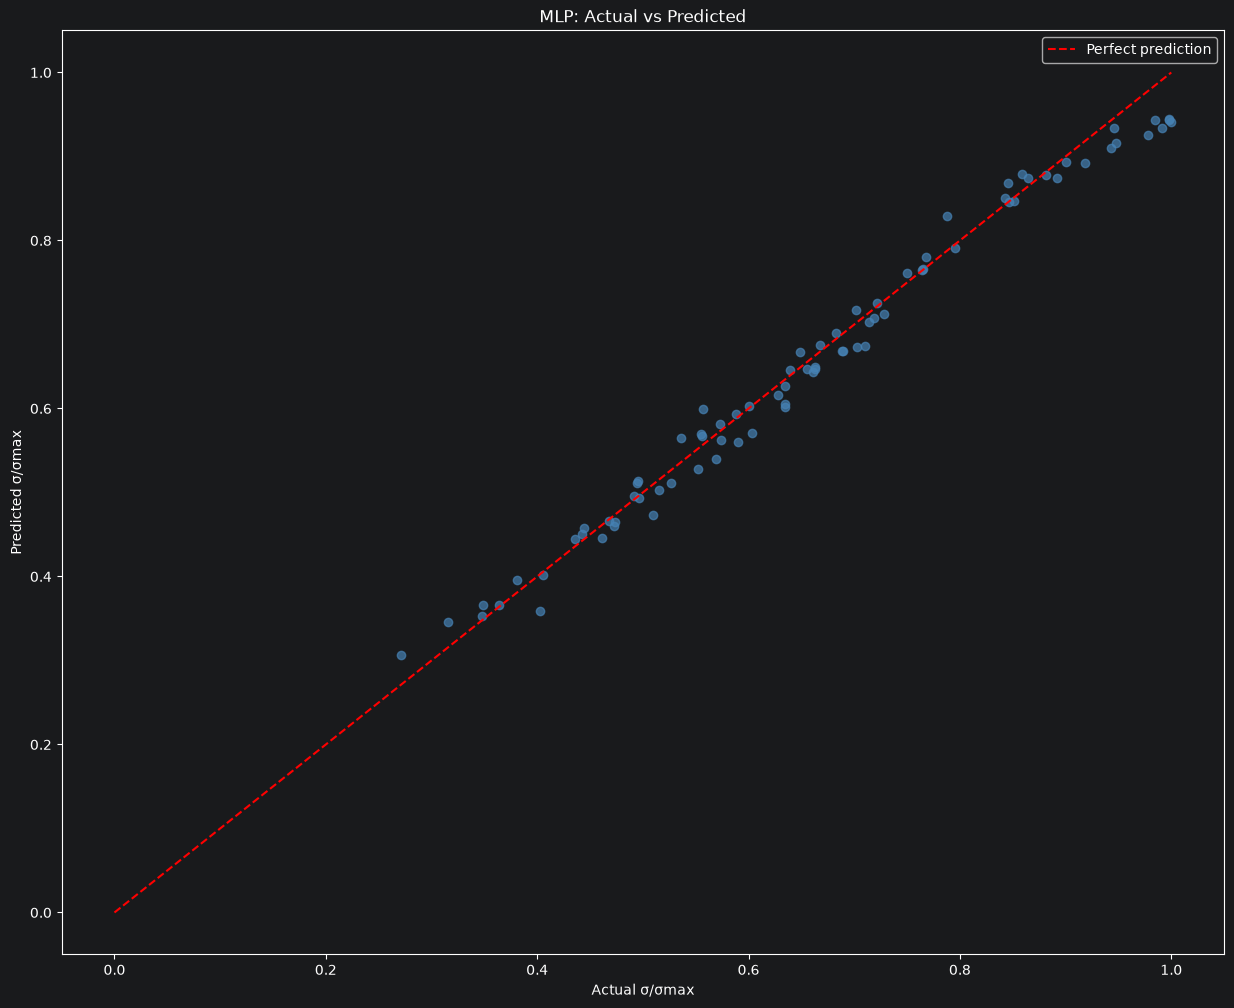

In [13]:
# Predicted vs Actual plot for MLP
plt.figure(figsize=(15,12))
plt.scatter(y_test, mlp_pred, alpha=0.7, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('Actual σ/σmax')
plt.ylabel('Predicted σ/σmax')
plt.title('MLP: Actual vs Predicted')
plt.legend()
plt.show()

In [14]:
# Save the model
mlp_model.save('../artifacts/mlp_model.h5')
print("Model saved successfully")

Model saved successfully


In [15]:
# Save tree-based models — needed as surrogates for derivative-free optimizers
joblib.dump(rf_model, '../artifacts/rf_model.pkl')
joblib.dump(xgb_model, '../artifacts/xgb_model.pkl')

print("Random Forest and XGBoost models saved successfully")

Random Forest and XGBoost models saved successfully


## Baseline Model Comparison

Four baseline models were trained and evaluated on the same test set using five performance metrics: **R², RMSE, MAE, MAPE,** and **Maximum Absolute Error (MaxAE)**. The MLP was trained separately and is discussed in the following sections.

| Model | R² | RMSE | MAE | MAPE | MaxAE |
|-------|------:|------:|------:|------:|------:|
| XGBoost | 0.9935 | 0.0150 | 0.0109 | 0.0186 | 0.0475 |
| SVR | 0.9923 | 0.0163 | 0.0119 | 0.0196 | 0.0487 |
| Random Forest | 0.9901 | 0.0185 | 0.0132 | 0.0231 | 0.0626 |
| Linear Regression | 0.9590 | 0.0377 | 0.0294 | 0.0482 | 0.1506 |

Linear Regression establishes the performance baseline, achieving an R² of **0.9590** and the largest maximum error (**0.1506**). These results confirm that the relationship between the processing parameters and flow stress is highly nonlinear and cannot be adequately represented by a simple linear model.

Among the nonlinear approaches, both Random Forest and SVR performed exceptionally well, with R² values exceeding **0.99**. SVR maintained a slight advantage over Random Forest across all evaluation metrics.

XGBoost delivered the strongest overall performance, producing the highest R² together with the lowest RMSE, MAE, MAPE, and MaxAE. Its smaller maximum error also indicates more reliable predictions under the most difficult test cases.

### Why the MLP Is Still Used as the Optimization Surrogate

Although XGBoost achieved the highest predictive accuracy, it is not suitable for the optimization stage of this study. Tree-based models such as XGBoost and Random Forest generate piecewise constant prediction surfaces through decision-tree splits, making them non-differentiable. As a result, they cannot provide the gradients required by gradient-based optimization algorithms.

The MLP, on the other hand, is composed entirely of differentiable mathematical operations. This allows gradients to be computed throughout the network, making it compatible with the optimization strategy implemented in `05_optimization.ipynb`. Therefore, the MLP is selected not because it is the most accurate predictive model, but because it is the only model capable of supporting gradient-based optimization.

---

## Training vs Validation Loss

The training and validation loss curves show that the network learned rapidly during the early stages of training. Within the first ten epochs, training loss decreased from **0.0290** to **0.0051**, while validation loss dropped from **0.0192** to **0.0029**, indicating fast convergence.

After the initial learning phase, both curves continued to improve gradually. The lowest validation loss (**0.000404**) was achieved at **epoch 62**. Early stopping, configured with a patience of ten epochs while monitoring validation loss, halted training at **epoch 72**, after which the weights from epoch 62 were automatically restored.

Throughout training, the validation loss consistently remained lower than the training loss. For example, at epoch 62 the training loss was **0.0016**, whereas the validation loss was **0.0004**. This behavior is expected because Dropout regularization is applied only during training, where 20% of neurons are randomly deactivated, while all neurons remain active during validation. The absence of divergence between the two curves indicates that the model generalized well without showing evidence of overfitting.

---

## Training vs Validation MAE

The Mean Absolute Error (MAE) followed a similar trend throughout training. At the best-performing epoch (62), the training MAE was **0.0312**, while the validation MAE was **0.0140**. When training concluded at epoch 72, the corresponding training and validation MAE values were **0.0294** and **0.0188**, respectively.

As observed with the loss curves, validation MAE remained consistently lower than training MAE because Dropout was active only during training. This behavior reflects the effect of regularization rather than overfitting.

It is important to note that these values correspond to the normalized training and validation datasets used during model fitting. The held-out **test-set MAE** reported later is **0.0187**, which provides a more meaningful measure of the model's ability to generalize to unseen data.

---

## MLP: Actual vs Predicted

The actual-versus-predicted scatter plot demonstrates that most predictions closely follow the ideal 45° line, indicating that the model accurately captures the relationship between the input variables and flow stress across most of the testing range.

A small number of samples show larger deviations from the ideal line, consistent with the recorded **MaxAE of 0.0593**. Compared with the baseline models, this places the MLP behind XGBoost (**0.0475**) and SVR (**0.0487**) in terms of worst-case prediction error, while remaining slightly better than Random Forest (**0.0626**). Despite this, the overall agreement between predicted and actual values remains strong, supporting the MLP's suitability as a surrogate model.

---

## Model Training Conclusions

Five machine learning models were trained and evaluated using identical training and testing datasets. Model performance was assessed using **R², RMSE, MAE, MAPE,** and **Maximum Absolute Error (MaxAE)**.

| Model | R² | RMSE | MAE | MAPE | MaxAE |
|-------|------:|------:|------:|------:|------:|
| XGBoost | 0.9935 | 0.0150 | 0.0109 | 0.0186 | 0.0475 |
| SVR | 0.9923 | 0.0163 | 0.0119 | 0.0196 | 0.0487 |
| Random Forest | 0.9901 | 0.0185 | 0.0132 | 0.0231 | 0.0626 |
| MLP (ANN) | 0.9838 | 0.0237 | 0.0187 | 0.0298 | 0.0593 |
| Linear Regression | 0.9590 | 0.0377 | 0.0294 | 0.0482 | 0.1506 |

XGBoost achieved the highest predictive accuracy, outperforming all other models across every evaluation metric. SVR and Random Forest also demonstrated excellent predictive capability, both achieving R² values above **0.99**. The MLP produced slightly lower predictive accuracy than the other nonlinear models, although an R² of **0.9838** still indicates excellent agreement between predicted and observed flow stress values. Linear Regression produced the weakest performance, reinforcing the nonlinear nature of the underlying process.

### Why the MLP Is Selected for Optimization

The MLP is selected as the surrogate model for the optimization stage because it provides a fully differentiable approximation of the process. Unlike tree-based models, which generate discontinuous prediction surfaces, neural networks produce smooth gradients that can be exploited by gradient-based optimization algorithms such as **L-BFGS-B**. Although this choice sacrifices a small amount of predictive accuracy compared with XGBoost, it enables efficient optimization of the process parameters, which is the primary objective of the next stage of this work.

The trained MLP was saved as `artifacts/mlp_model.h5`, while the Random Forest and XGBoost models were saved as `artifacts/rf_model.pkl` and `artifacts/xgb_model.pkl`, respectively. The tree-based models are subsequently used as surrogate models for derivative-free optimization methods in the following notebook.